<a href="https://colab.research.google.com/github/parika8ec-hub/AI_Assignment_12/blob/main/Assignment12.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task-1: Dataset Preparation

**Dataset Choice:**

The CIFAR-10 dataset is the stronger option, which can show clear distinctions between deep learning and traditional ML capabilities. It contains 60000 small (32x32) color images across 10 classes like airplanes, cars, birds, cats and ships. This dataset also includes the more complex images as color, background variation and object position so traditional ML models like SVM or logistic regression struggle without heavy feature engineering. In contrast, deep learning models like CNNs automatically learn spatial features and perform significantly better.

**Data Loading and Visualization:**

In [15]:
#Import libraries
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten

In [2]:
# Load CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
#Display shape of train and test dataset
print("Training data shape:", x_train.shape)
print("Test data shape:", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Training data shape: (50000, 32, 32, 3)
Test data shape: (10000, 32, 32, 3)


In [3]:
#Define class names
class_names = ["airplane", "automobile", "bird", "cat", "deer","dog", "frog", "horse", "ship", "truck"]

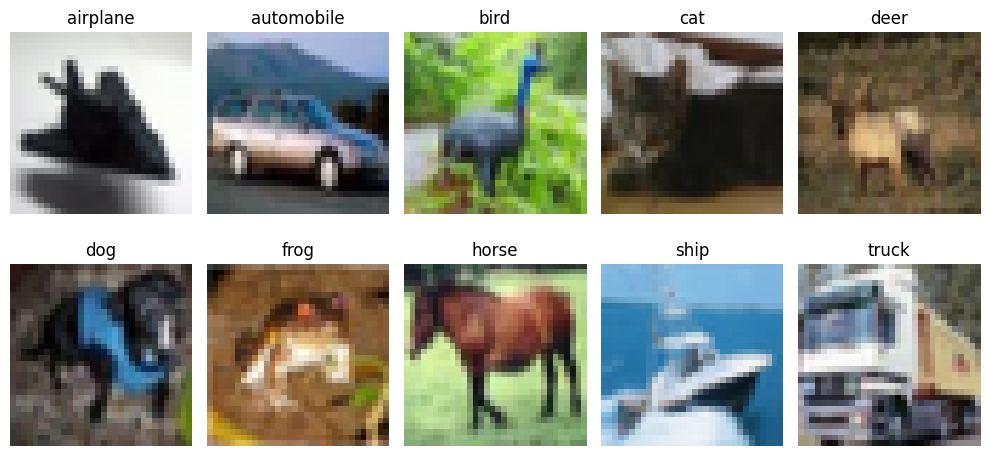

In [4]:
#Visualize One Sample from Each Class
plt.figure(figsize=(10, 5))#set image plot size
#Take each class index
for i in range(10):
    ## Get the index of the first image in the dataset that belongs to class 'i' where y_train.flatten() converts labels into a 1D array
    idx = np.where(y_train.flatten() == i)[0][0]
    plt.subplot(2, 5, i + 1)#create subplots
    plt.imshow(x_train[idx])#show image
    plt.title(class_names[i])#add title
    plt.axis('off')#off axis

plt.tight_layout()#take tight layout
plt.show()#display image plot

# Task-2 Image Preprocessing

**Normalization:**

In [5]:
#Normalize pixel values
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Flatten separately for normal training
x_train_flat = x_train.reshape(x_train.shape[0], -1)# (50000, 3072)
x_test_flat = x_test.reshape(x_test.shape[0], -1) # (10000, 3072)

#One-hot encode labels
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

**Data Augmentation:**

In [6]:
# Data Augmentation:
'''
To improve model robustness, optionally augment the training data using transformations like rotation, translation, scaling and horizontal flipping using
ImageDataGenerator in Keras.
'''
# Create an ImageDataGenerator object for data augmentation
datagen = ImageDataGenerator(
    rotation_range=15,         # randomly rotate images up to 15 degrees
    width_shift_range=0.1,     # randomly shift images horizontally (10% of width)
    height_shift_range=0.1,    # randomly shift images vertically (10% of height)
    zoom_range=0.1,            # randomly zoom in or out by 10%
    horizontal_flip=True       # randomly flip images horizontally
)

# Define batch size for training (number of images processed at once)
batch_size = 64

# Generate augmented image batches from training data and images are original 32x32x3 images ,not flattened
train_generator = datagen.flow(x_train, y_train, batch_size=batch_size, shuffle=True)

# Task-3: Neural Network Implementation

**Model Architecture and Compilation:**

In [7]:
# Import Sequential model and Dense layer
basic_model = Sequential([

    # Input layer + first hidden layer takes flattened CIFAR-10 images (32×32×3 = 3072 features) and 512 neurons with ReLU activation to learn complex patterns
    Dense(512, activation='relu', input_shape=(3072,)),

    # Second hidden layer reduces dimensionality and extracts higher-level features
    Dense(256, activation='relu'),

    # Output layer shows 10 neurons (one for each class) with Softmax activation and probability distribution across 10 classes
    Dense(10, activation='softmax')
])
# Compile model using Adam optimizer, categorical crossentropy loss, and accuracy metric
basic_model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


**Model Training:**

In [8]:
print("\nTraining Basic Model...\n")

# Train the neural network model on training data
history_basic = basic_model.fit(

    x_train_flat, y_train,          # input features (images) and corresponding labels

    batch_size=32,             # number of samples processed before updating model weights

    epochs=10,                 # number of complete passes through the entire training dataset

    validation_split=0.2       # reserve 20% of training data for validation (used to monitor performance)
)


Training Basic Model...

Epoch 1/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 34s 25ms/step - accuracy: 0.3199 - loss: 1.8795 - val_accuracy: 0.3710 - val_loss: 1.7394
Epoch 2/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 28s 23ms/step - accuracy: 0.3936 - loss: 1.6915 - val_accuracy: 0.4059 - val_loss: 1.6705
Epoch 3/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 41s 23ms/step - accuracy: 0.4238 - loss: 1.6042 - val_accuracy: 0.4028 - val_loss: 1.6511
Epoch 4/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 42s 23ms/step - accuracy: 0.4455 - loss: 1.5516 - val_accuracy: 0.4251 - val_loss: 1.6055
Epoch 5/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 41s 23ms/step - accuracy: 0.4584 - loss: 1.5102 - val_accuracy: 0.4483 - val_loss: 1.5559
Epoch 6/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 28s 23ms/step - accuracy: 0.4700 - loss: 1.4800 - val_accuracy: 0.4530 - val_loss: 1.5375
Epoch 7/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 30s 24ms/step - accuracy: 0.4762 - loss: 1.4563 - val_accuracy: 0.4597 - val_loss: 1.5110
Epoch 8/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 33s 27ms

# Task-4: Model Evaluation


**Performance Metrics:**

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step

Basic Model Performance:
Accuracy: 0.4761
Precision: 0.47735543864803187
Recall: 0.4761
F1-score: 0.4663361003807107

Classification Report:

              precision    recall  f1-score   support

           0       0.49      0.64      0.55      1000
           1       0.64      0.57      0.60      1000
           2       0.38      0.33      0.35      1000
           3       0.36      0.21      0.26      1000
           4       0.44      0.33      0.38      1000
           5       0.43      0.34      0.38      1000
           6       0.40      0.67      0.50      1000
           7       0.49      0.61      0.54      1000
           8       0.64      0.47      0.54      1000
           9       0.51      0.60      0.55      1000

    accuracy                           0.48     10000
   macro avg       0.48      0.48      0.47     10000
weighted avg       0.48      0.48      0.47     10000

Confusion Matrix:
[[637  33  53  10  24  15  34  53  80  

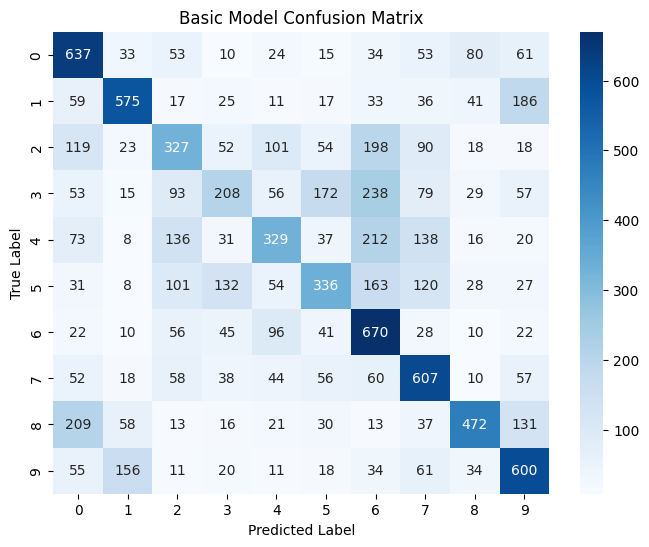

In [11]:
# Predict class probabilities
y_pred_probs = basic_model.predict(x_test_flat)

# Convert probabilities to class labels
y_pred = np.argmax(y_pred_probs, axis=1)

# Convert one-hot encoded y_test back to labels
y_true = np.argmax(y_test, axis=1)

#Performance Metrics

#Compute accuracy_score, precion_score, recall_score and f1_score
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

print("\nBasic Model Performance:")
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

#Display classification report
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred))

#Create confusion matrix
cm = confusion_matrix(y_true, y_pred)
print('Confusion Matrix:')
print(cm)

#Plot confusion matrix
plt.figure(figsize=(8,6))#set plot size
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')#create heatmap
#add label of axis and title
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Basic Model Confusion Matrix")
plt.show()#display plot

**Model Improvements:**


1) Improved Model Architecture with Dropout:

In [12]:
#Improved model with dropout

# Define a Sequential feedforward neural network model with Dropout
improved_model = Sequential([

    # Input layer + first hidden layer takes flattened image input (32x32x3 = 3072 features) and 512 neurons with ReLU activation to learn complex patterns
    Dense(512, activation='relu', input_shape=(3072,)),

    # Dropout layer used to randomly drops 30% of neurons during training to reduce overfitting
    Dropout(0.3),

    # Second hidden layer learns more abstract features with fewer neurons
    Dense(256, activation='relu'),

    # Dropout layer again drops 30% of neurons to improve generalization
    Dropout(0.3),

    # Third hidden layer used to further refines learned features
    Dense(128, activation='relu'),

    # Output layer shows 10 neurons (for 10 classes) with Softmax activation and probability distribution across classes
    Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2) Improved Model Compilation:

In [13]:
# Compile the neural network model
improved_model.compile(

    # Optimizer as 'rmsprop' adjusts learning rates automatically for each parameter and helps faster convergence, especially for neural networks and complex data
    optimizer='rmsprop',

    # Loss function used for multi-class classification with one-hot encoded labels and measures difference between predicted and actual class probabilities
    loss='categorical_crossentropy',

    # Evaluation metric used to tracks the proportion of correctly classified samples during training/testing
    metrics=['accuracy']
)

3. Improved Model Training:

In [14]:
print("\nTraining Improved Model...\n")

# Train the neural network model on the training dataset
history_improved=improved_model.fit(
    x_train_flat, y_train,          # input data (features) and corresponding labels

    batch_size=32,             # 32 number of samples processed before updating weights

    epochs=20,                 # 20 number of times the model sees the entire dataset

    validation_split=0.2       # use 20% of training data for validation during training
)


Training Improved Model...

Epoch 1/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 29s 23ms/step - accuracy: 0.2331 - loss: 2.0708 - val_accuracy: 0.3182 - val_loss: 1.8983
Epoch 2/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 27s 21ms/step - accuracy: 0.2946 - loss: 1.9218 - val_accuracy: 0.3152 - val_loss: 1.8696
Epoch 3/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 49s 28ms/step - accuracy: 0.3160 - loss: 1.8868 - val_accuracy: 0.3286 - val_loss: 1.8709
Epoch 4/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 43s 29ms/step - accuracy: 0.3251 - loss: 1.8650 - val_accuracy: 0.3675 - val_loss: 1.8222
Epoch 5/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 28s 22ms/step - accuracy: 0.3320 - loss: 1.8463 - val_accuracy: 0.3600 - val_loss: 1.8015
Epoch 6/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 53s 32ms/step - accuracy: 0.3387 - loss: 1.8395 - val_accuracy: 0.3878 - val_loss: 1.7684
Epoch 7/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 46s 37ms/step - accuracy: 0.3390 - loss: 1.8295 - val_accuracy: 0.3703 - val_loss: 1.8051
Epoch 8/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 35s 2

4) Improved Model Evaluation:

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step

Improved Model Performance:
Accuracy: 0.3993
Precision: 0.4404844553766293
Recall: 0.3993
F1-score: 0.3902543408010926

Classification Report:

              precision    recall  f1-score   support

           0       0.51      0.35      0.42      1000
           1       0.60      0.41      0.49      1000
           2       0.29      0.25      0.27      1000
           3       0.26      0.33      0.29      1000
           4       0.40      0.32      0.36      1000
           5       0.55      0.11      0.19      1000
           6       0.30      0.72      0.42      1000
           7       0.58      0.41      0.48      1000
           8       0.46      0.56      0.50      1000
           9       0.46      0.53      0.49      1000

    accuracy                           0.40     10000
   macro avg       0.44      0.40      0.39     10000
weighted avg       0.44      0.40      0.39     10000

Confusion Matrix:
[[351  18 153  67  22   2  76  26 226

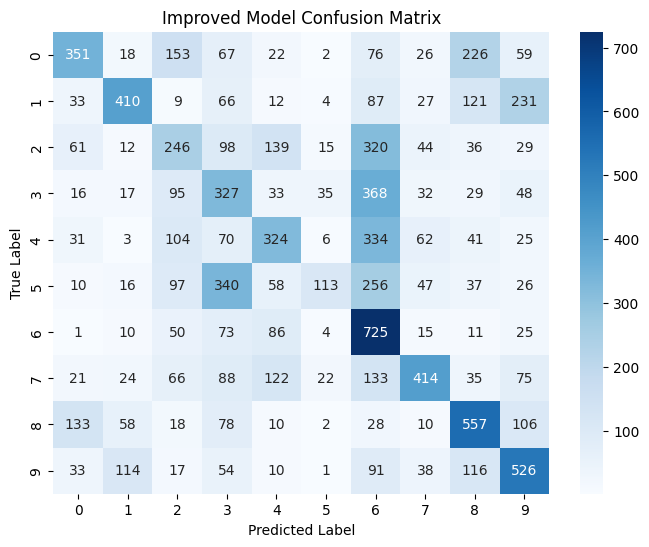

In [16]:
# Predict class probabilities
y_pred_probs_improved = improved_model.predict(x_test_flat)

# Convert probabilities to class labels
y_pred_improved = np.argmax(y_pred_probs_improved, axis=1)

# Convert one-hot encoded y_test back to labels
y_true_improved = np.argmax(y_test, axis=1)

#Performance Metrics

#Compute accuracy_score, precion_score, recall_score and f1_score
accuracy_improved = accuracy_score(y_true_improved, y_pred_improved)
precision_improved = precision_score(y_true_improved, y_pred_improved, average='weighted')
recall_improved = recall_score(y_true_improved, y_pred_improved, average='weighted')
f1_improved = f1_score(y_true_improved, y_pred_improved, average='weighted')

print("\nImproved Model Performance:")
print("Accuracy:", accuracy_improved)
print("Precision:", precision_improved)
print("Recall:", recall_improved)
print("F1-score:", f1_improved)

#Display classification report
print("\nClassification Report:\n")
print(classification_report(y_true_improved, y_pred_improved))

#Create confusion matrix
cm_improved = confusion_matrix(y_true_improved, y_pred_improved)
print('Confusion Matrix:')
print(cm_improved)

#Plot confusion matrix
plt.figure(figsize=(8,6))#set plot size
sns.heatmap(cm_improved, annot=True, fmt='d', cmap='Blues')#create heatmap
#add label of axis and title
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Improved Model Confusion Matrix")
plt.show()#display plot

**Note: Data augmentation was not applied during the training and evaluation of the basic and improved models; their results represent baseline performance.**

**Augmentation Model:**

1) Augmentation Model Architecture, Compilation and Training:

In [17]:
# Create CNN model for training on augmented image data
aug_model = Sequential([

    # First convolution layer extracts basic image features like edges and patterns
    Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),

    # Reduce image dimensions while keeping important features
    MaxPooling2D(pool_size=(2,2)),

    # Second convolution layer learns more complex features
    Conv2D(64, (3,3), activation='relu'),

    # Further reduce feature map size
    MaxPooling2D(pool_size=(2,2)),

    # Convert 2D feature maps into 1D vector for dense layers
    Flatten(),

    # Fully connected layer learns high-level patterns
    Dense(128, activation='relu'),

    # Dropout helps reduce overfitting by randomly dropping neurons
    Dropout(0.3),

    # Output layer with 10 neurons for CIFAR-10 classification
    Dense(10, activation='softmax')
])

# Compile model using Adam optimizer, categorical crossentropy loss and accuracy metric
aug_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("\nTraining Improved Model...\n")

# Train CNN model using augmented training images and validate on test data
history_aug = aug_model.fit(
    train_generator,            # augmented training images
    epochs=10,                  # number of training iterations
    validation_data=(x_test, y_test)   # evaluate performance on unseen test data
)


Training Improved Model...

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


782/782 ━━━━━━━━━━━━━━━━━━━━ 122s 154ms/step - accuracy: 0.3867 - loss: 1.6745 - val_accuracy: 0.5326 - val_loss: 1.3091
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 83s 107ms/step - accuracy: 0.4985 - loss: 1.4014 - val_accuracy: 0.5433 - val_loss: 1.2830
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 82s 105ms/step - accuracy: 0.5382 - loss: 1.2949 - val_accuracy: 0.5987 - val_loss: 1.1149
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 87s 112ms/step - accuracy: 0.5644 - loss: 1.2290 - val_accuracy: 0.6266 - val_loss: 1.0689
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 83s 106ms/step - accuracy: 0.5829 - loss: 1.1833 - val_accuracy: 0.6540 - val_loss: 0.9809
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 81s 104ms/step - accuracy: 0.5962 - loss: 1.1473 - val_accuracy: 0.6363 - val_loss: 1.0425
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 81s 104ms/step - accuracy: 0.6052 - loss: 1.1194 - val_accuracy: 0.6661 - val_loss: 0.9472
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 82s 104ms/step - accuracy: 0.6132 - loss: 1.1001 - va

2) Augmentation Model Evaluation:

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step

Augmented Model Performance:
Accuracy: 0.6899
Precision: 0.6880391742008536
Recall: 0.6899
F1-score: 0.6826691386059055

Classification Report:

              precision    recall  f1-score   support

           0       0.69      0.76      0.72      1000
           1       0.76      0.84      0.80      1000
           2       0.68      0.46      0.55      1000
           3       0.60      0.45      0.51      1000
           4       0.63      0.58      0.61      1000
           5       0.65      0.57      0.61      1000
           6       0.71      0.80      0.75      1000
           7       0.65      0.79      0.72      1000
           8       0.85      0.79      0.82      1000
           9       0.66      0.85      0.74      1000

    accuracy                           0.69     10000
   macro avg       0.69      0.69      0.68     10000
weighted avg       0.69      0.69      0.68     10000

Confusion Matrix:
[[760  38  38   8  11   3   6  16  

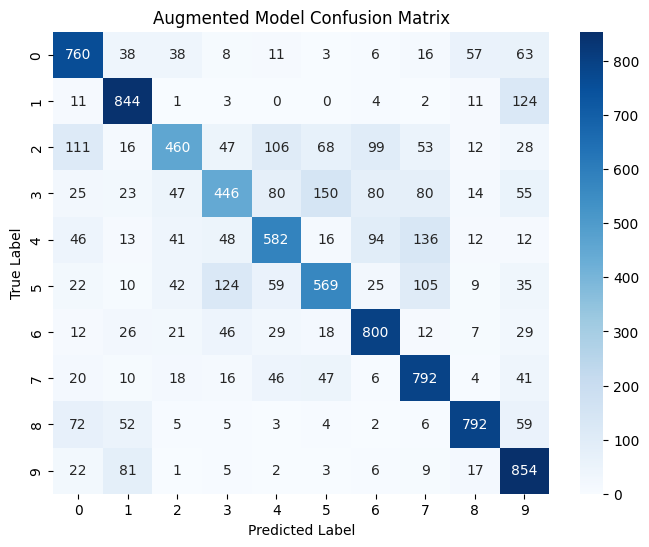

In [18]:
# Predict class probabilities
y_pred_probs_aug = aug_model.predict(x_test)

# Convert probabilities into class labels
y_pred_aug = np.argmax(y_pred_probs_aug, axis=1)

# Convert one-hot labels back to actual labels
y_true_aug = np.argmax(y_test, axis=1)


# Performance metrics
accuracy_aug = accuracy_score(y_true_aug, y_pred_aug)
precision_aug = precision_score(y_true_aug, y_pred_aug, average='weighted')
recall_aug = recall_score(y_true_aug, y_pred_aug, average='weighted')
f1_aug = f1_score(y_true_aug, y_pred_aug, average='weighted')

print("\nAugmented Model Performance:")
print("Accuracy:", accuracy_aug)
print("Precision:", precision_aug)
print("Recall:", recall_aug)
print("F1-score:", f1_aug)

#Display classification report
print("\nClassification Report:\n")
print(classification_report(y_true_aug, y_pred_aug))

#Create confusion matrix
cm_aug = confusion_matrix(y_true_aug, y_pred_aug)
print('Confusion Matrix:')
print(cm_aug)

#Plot confusion matrix
plt.figure(figsize=(8,6))#set plot size
sns.heatmap(cm_aug, annot=True, fmt='d', cmap='Blues')#create heatmap
#add label of axis and title
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Augmented Model Confusion Matrix")
plt.show()#display plot

**Impact of data augmentation on model performance:**

The basic model, trained without data augmentation, achieved an accuracy of 47.61% with an F1-score of 46.63%. It performed reasonably well on classes such as automobiles, frogs, horses and trucks, but struggled to classify visually similar categories like cats, dogs, deer and birds. This indicates that the simple feedforward network had limited ability to capture complex image features.

The improved model, which included additional layers and dropout regularization but was still trained without augmentation, performed worse with an accuracy of only 39.93% and an F1-score of 39.03%. Although dropout was added to reduce overfitting, the model likely became harder to optimize on flattened image data, resulting in lower overall performance.

The augmented model showed the best performance with a significant accuracy improvement to 68.99% and an F1-score of 68.27%. By applying transformations such as rotation, shifting, zooming and horizontal flipping, the model was exposed to more diverse training examples, which improved its ability to generalize to unseen test images. The confusion matrix also shows fewer misclassifications across most classes, particularly for automobiles, frogs, ships and trucks.

Overall, data augmentation had a strong positive impact, improving accuracy by approximately 21% compared to the basic model and nearly 29% compared to the improved model. This demonstrates that augmenting training data helps deep learning models become more robust and reduces overfitting, especially when combined with CNN architecture that preserves spatial image features.

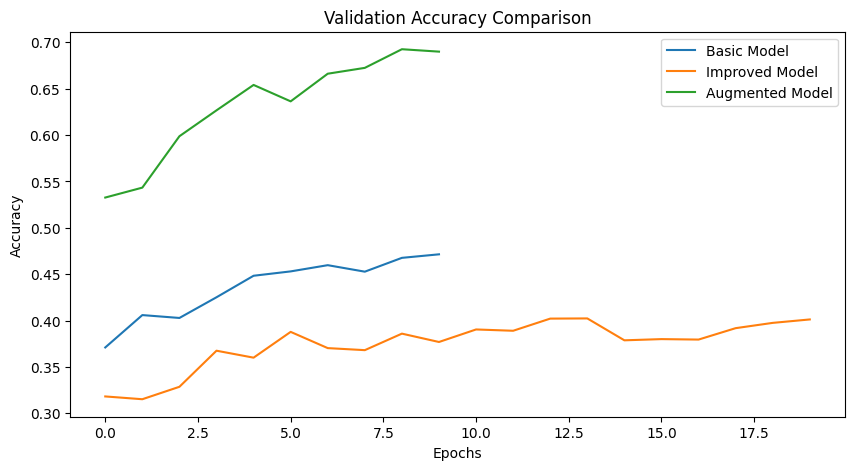

In [21]:
#Accuracy Comparison Plot
plt.figure(figsize=(10,5))#set plot size

# Basic model
plt.plot(history_basic.history['val_accuracy'], label='Basic Model')

# Improved model
plt.plot(history_improved.history['val_accuracy'], label='Improved Model')

# Augmented model
plt.plot(history_aug.history['val_accuracy'], label='Augmented Model')
#Add title,label of axis and legend
plt.title('Validation Accuracy Comparison')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()#display plot

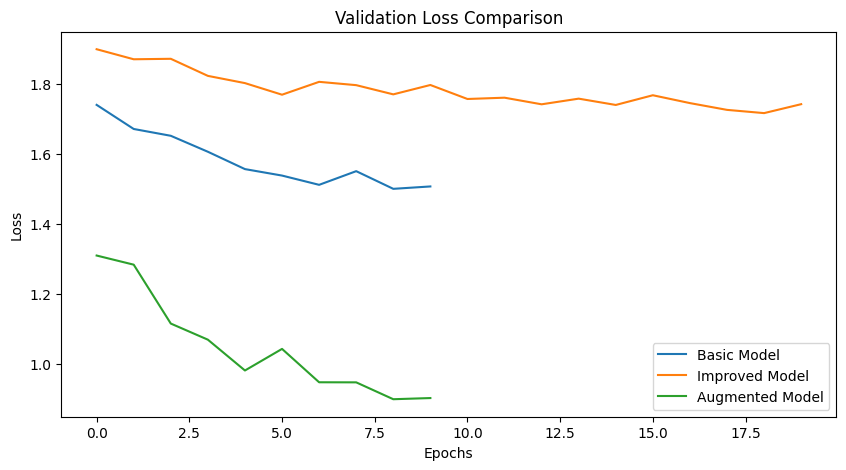

In [22]:
#Accuracy Comparison Plot
plt.figure(figsize=(10,5))#set plot size

# Basic model
plt.plot(history_basic.history['val_loss'], label='Basic Model')

# Improved model
plt.plot(history_improved.history['val_loss'], label='Improved Model')

# Augmented model
plt.plot(history_aug.history['val_loss'], label='Augmented Model')
#Add title,label of axis and legend
plt.title('Validation Loss Comparison')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()#display plot

# Task-5:Application Demonstration

Practical Deployment Scenario:

**1) Hypothetical application of the trained model in a real-world scenario:**

A hypothetical real-world application of the trained image classification model could be in digital media organization. For example, a photo management platform like Google Photos or Apple Photos could use a similar model to automatically classify and organize uploaded images into categories such as vehicles, animals, or transportation objects. If a user uploads thousands of photos, the model can automatically identify images containing airplanes, cars, ships, trucks, dogs, or birds and group them into labeled albums. This would make it easier for users to search for specific photos without manually sorting them.

Data augmentation would be especially useful in this scenario because real-world images are often captured from different angles, lighting conditions, and backgrounds. Since the augmented model achieved higher accuracy and better generalization, it would be more reliable when classifying diverse user images. Such an application could improve user experience by saving time, enhancing search functionality, and enabling smarter photo organization systems.

**2) Address potential operational issues with existing technology:**

In a real-world digital media organization system, several operational challenges must be considered before deploying the image classification model.

**Model scalability:** Platforms like Google Photos handle large volumes of image uploads, so the model must scale efficiently using cloud infrastructure and GPU support.

**Real-time processing:** Users expect instant results, so the model should classify images quickly using optimized or lightweight techniques to reduce latency.

**Integration with existing systems:** The model must connect with storage systems, databases and mobile apps through APIs to ensure smooth functionality across platforms.

**Data privacy and security:** Since images may contain sensitive data, proper security measures and privacy compliance are essential.

Overall, successful deployment requires addressing scalability, speed, integration and security challenges.